In [ ]:
import requests
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from datetime import datetime, timedelta
from torch.utils.data import Dataset, DataLoader
from collections.abc import Sized
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from pandas.tseries.offsets import QuarterEnd
from typing import Any

In [ ]:

API_KEY = "JcmfjzcBwo5HGSiM5Yib7ylfG2PmSNzc"
TICKER  = "LULU"

def fetch_all_history(ticker: str, api_key: str) -> pd.DataFrame:
    """
    Fetch full OHLCV history for `ticker`, then compute:
      - 3-day forward return
      - 3-day realized volatility (std of daily returns)
    """
    all_chunks = []
    to_date = datetime.today().date()
    chunk_size = 1500

    while True:
        from_date = to_date - timedelta(days=int(chunk_size*1.5))
        url = (
            f"https://financialmodelingprep.com/api/v3/historical-price-full/{ticker}"
            f"?from={from_date:%Y-%m-%d}&to={to_date:%Y-%m-%d}"
            f"&apikey={api_key}"
        )
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        data = resp.json().get("historical", [])
        if not data:
            break

        df_chunk = pd.DataFrame(data)[["date","open","high","low","close","volume"]]
        df_chunk["date"] = pd.to_datetime(df_chunk["date"])
        all_chunks.append(df_chunk)

        earliest = df_chunk["date"].min().date()
        if (to_date - earliest).days < 2:
            break
        to_date = earliest - timedelta(days=1)

    # combine
    df = pd.concat(all_chunks, ignore_index=True)
    df = df.drop_duplicates(subset="date").sort_values("date").reset_index(drop=True)

    # compute 3-day forward return
    df["Return_3D"] = df["close"].pct_change(periods=3).shift(-3)

    # compute daily return & 3-day rolling volatility of returns
    df["Return_1D"] = df["close"].pct_change()
    df["Volatility_3D"] = df["Return_1D"].rolling(window=3).std()

    # drop rows with NaNs at start
    df = df.dropna(subset=["Return_3D","Volatility_3D"]).reset_index(drop=True)
    return df

if __name__ == "__main__":
    df = fetch_all_history(TICKER, API_KEY)

    # write out with the new features
    df.to_csv(
        f"{TICKER}_full_history_with_features.csv",
        index=False,
        columns=[
            "date","open","high","low","close","volume",
            "Return_3D","Volatility_3D"
        ],
        date_format="%Y-%m-%d"
    )

    print(df.head(10)[
        ["date","open","high","low","close","volume","Return_3D","Volatility_3D"]
    ].to_csv(index=False))


date,open,high,low,close,volume,Return_3D,Volatility_3D
2007-08-01,16.49,16.625,15.2,15.595,3024484,0.051984610452067814,0.05451602152994228
2007-08-02,16.0,16.915,15.99,16.57,1969972,0.09384429692214846,0.05205853814495422
2007-08-03,17.225,17.25,15.045,15.5,2349364,0.217741935483871,0.0650757147624308
2007-08-06,15.95,16.425,15.045,16.4057,3002882,0.07432172964274608,0.07222696903774908
2007-08-07,16.395,18.515,16.065,18.125,3983002,-0.0027586206896552667,0.08752896051319489
2007-08-08,18.52,19.425,18.2,18.875,4068200,-0.02437086092715235,0.03281951159324735
2007-08-09,18.25,18.875,17.25,17.625,1828562,-0.03546099290780147,0.08645809987425221
2007-08-10,17.01,18.1,16.13,18.075,2232672,-0.07192254495159067,0.058093638481152524
2007-08-13,18.76,19.0,18.255,18.415,962774,-0.12489818083084447,0.051146204634720686
2007-08-14,18.5,18.595,16.745,17.0,2153420,-0.02941176470588236,0.05726258473282857



In [412]:
# def winsorize_df(df, cols=None, lower_pct=0.01, upper_pct=0.99):
#     """
#     Caps values below the lower_pct quantile to that quantile,
#     and above the upper_pct quantile to that quantile, for each column in cols.
#     If cols is None, all numeric columns are winsorized.
#     """
#     df = df.copy()
#     if cols is None:
#         cols = df.select_dtypes(include="number").columns.tolist()
#     for col in cols:
#         lower = df[col].quantile(lower_pct)
#         upper = df[col].quantile(upper_pct)
#         df[col] = df[col].clip(lower, upper)
#     return df

# numeric_cols = ["open", "high", "low", "close", "volume"]
# df_wins = winsorize_df(df, cols=numeric_cols, lower_pct=0.01, upper_pct=0.99)

In [413]:
def prepare_data_quarterly_minmax(df, feature_cols, target_col='Return_1D', window_size=60):
    df = df.copy()
    df['Quarter'] = df.index.to_period('Q')
    
    scaled_chunks = []
    scalers = {}
    
    for quarter, group in df.groupby('Quarter'):
        chunk = group[feature_cols + [target_col]].copy()
        if len(chunk) < window_size:
            continue
        scaler = MinMaxScaler()
        scaled_values = scaler.fit_transform(chunk)
        scaled_chunk = pd.DataFrame(scaled_values, columns=feature_cols + [target_col], index=chunk.index)
        scaled_chunks.append(scaled_chunk)
        scalers[str(quarter)] = scaler

    df_scaled = pd.concat(scaled_chunks).sort_index()
    df_scaled.dropna(inplace=True)

    data = df_scaled[feature_cols].values
    target = df_scaled[target_col].values
    X, y = [], []
    for i in range(window_size, len(df_scaled)):
        X.append(data[i - window_size:i])
        y.append(target[i])
    
    return np.array(X), np.array(y), scalers, df_scaled


In [414]:
class StockDataset(Dataset):
    def __init__(self, X: Any, y: Any):
        self.X = X
        self.y = y

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]
    
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=100, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        c0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])


In [415]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.should_stop = False
    def __call__(self, val_loss):
        if self.best_loss is None or self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


In [416]:
def compute_indicators(df):
    df = df.rename(columns={
        'open': 'Open', 
        'high': 'High', 
        'low': 'Low', 
        'close': 'Close', 
        'volume': 'Volume'
    })
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -1 * delta.clip(upper=0)
    roll_up = gain.ewm(span=14).mean()
    roll_down = loss.ewm(span=14).mean()
    rs = roll_up / roll_down
    df['RSI'] = 100.0 - (100.0 / (1.0 + rs))
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9, adjust=False).mean()
    df['MACD'] = macd
    df['MACD_Signal'] = signal
    df['MACD_Hist'] = macd - signal
    sma = df['Close'].rolling(window=20).mean()
    std = df['Close'].rolling(window=20).std()
    df['BB_Mid'] = sma
    df['BB_Upper'] = sma + 2 * std
    df['BB_Lower'] = sma - 2 * std
    df['Return_1D'] = df['Close'].pct_change().shift(-1)
    df.dropna(inplace=True)
    return df

In [ ]:
WINDOW_SIZE = 30
EPOCHS = 200
BATCH_SIZE = 30
LR = 1e-3
HIDDEN_DIM = 100
NUM_LAYERS = 2
DROPOUT = 0.2
PATIENCE = 10
FINAL_HOLDOUT_SIZE = 200

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

df = fetch_all_history(TICKER, API_KEY)
df = compute_indicators(df)

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

feature_cols = [c for c in df.columns if c != "Return_1D"]
print("Features used as input to the LSTM:")
for feature in feature_cols:
    print("-", feature)

X, y, scalers, df_scaled = prepare_data_quarterly_minmax(df, feature_cols, target_col='Return_1D', window_size=WINDOW_SIZE)

Using device: cuda
Features used as input to the LSTM:
- Open
- High
- Low
- Close
- Volume
- Return_3D
- Volatility_3D
- RSI
- MACD
- MACD_Signal
- MACD_Hist
- BB_Mid
- BB_Upper
- BB_Lower


In [ ]:
split_point = len(X) - FINAL_HOLDOUT_SIZE
X_train_all, y_train_all = X[:split_point], y[:split_point]
X_test_final, y_test_final = X[split_point:], y[split_point:]

train_dataset = StockDataset(X_train_all, y_train_all)
test_dataset = StockDataset(X_test_final, y_test_final)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model     = LSTMModel(input_dim=len(feature_cols),
                      hidden_dim=HIDDEN_DIM,
                      num_layers=NUM_LAYERS,
                      dropout=DROPOUT).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
stopper = EarlyStopping(patience=PATIENCE)

train_losses = []
val_losses = []

In [ ]:
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.float().to(device)     
        y_batch = y_batch.float().to(device)     
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze(-1)      
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset) # type: ignore

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.float().to(device)
            outputs = model(X_batch).squeeze(-1)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(test_loader.dataset) # type: ignore

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1:03d}  Train Loss: {train_loss:.6f}  |  Val Loss: {val_loss:.6f}")

    stopper(val_loss)
    if stopper.should_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break


Epoch 001  Train Loss: 0.060028  |  Val Loss: 0.054972
Epoch 002  Train Loss: 0.035878  |  Val Loss: 0.029318
Epoch 003  Train Loss: 0.030878  |  Val Loss: 0.026254
Epoch 004  Train Loss: 0.029877  |  Val Loss: 0.024803
Epoch 005  Train Loss: 0.026792  |  Val Loss: 0.029081
Epoch 006  Train Loss: 0.020450  |  Val Loss: 0.015098
Epoch 007  Train Loss: 0.015554  |  Val Loss: 0.017345
Epoch 008  Train Loss: 0.014551  |  Val Loss: 0.016248
Epoch 009  Train Loss: 0.013797  |  Val Loss: 0.014969
Epoch 010  Train Loss: 0.012992  |  Val Loss: 0.013667
Epoch 011  Train Loss: 0.012231  |  Val Loss: 0.014009
Epoch 012  Train Loss: 0.012042  |  Val Loss: 0.014713
Epoch 013  Train Loss: 0.011774  |  Val Loss: 0.013066
Epoch 014  Train Loss: 0.011318  |  Val Loss: 0.013239
Epoch 015  Train Loss: 0.011193  |  Val Loss: 0.015296
Epoch 016  Train Loss: 0.010416  |  Val Loss: 0.012064
Epoch 017  Train Loss: 0.010356  |  Val Loss: 0.011860
Epoch 018  Train Loss: 0.009742  |  Val Loss: 0.010809
Epoch 019 

Train MSE: 0.004650
Train MAE: 0.050767
Train R²:   0.915745
Test MSE: 0.013379
Test MAE: 0.082771
Test R²:   0.760016


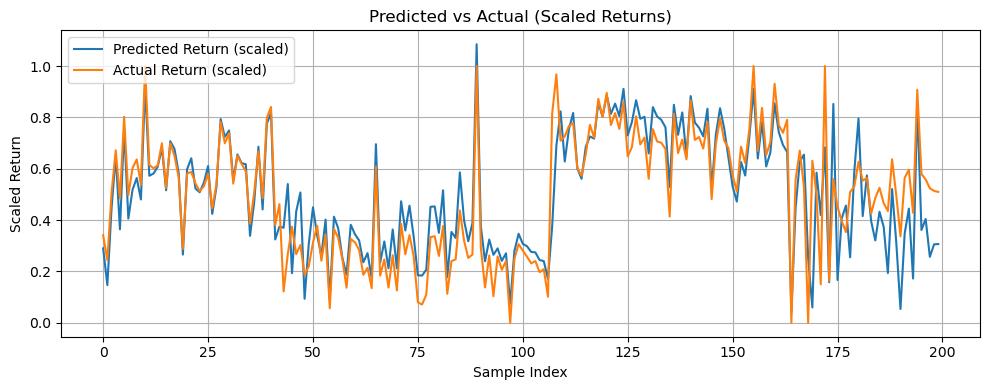

In [420]:
# Performance on Training Set
model.eval()
with torch.no_grad():
    X_train_tensor = torch.tensor(X_train_all).float().to(device)
    train_preds = model(X_train_tensor).cpu().numpy().ravel()

train_mse = mean_squared_error(y_train_all, train_preds)
train_mae = mean_absolute_error(y_train_all, train_preds)
train_r2 = r2_score(y_train_all, train_preds)

print(f"Train MSE: {train_mse:.6f}")
print(f"Train MAE: {train_mae:.6f}")
print(f"Train R²:   {train_r2:.6f}")


# Performance on Testing (Holdout) Set
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_final).float().to(device)
    test_preds = model(X_test_tensor).cpu().numpy().ravel()

test_mse = mean_squared_error(y_test_final, test_preds)
test_mae = mean_absolute_error(y_test_final, test_preds)
test_r2 = r2_score(y_test_final, test_preds)

print(f"Test MSE: {test_mse:.6f}")
print(f"Test MAE: {test_mae:.6f}")
print(f"Test R²:   {test_r2:.6f}")


# Plot Predicted vs Actual for Holdout Set
df_result = pd.DataFrame({
    "Predicted Return (scaled)": test_preds,
    "Actual Return (scaled)": y_test_final
})

df_result.plot(figsize=(10, 4), title="Predicted vs Actual (Scaled Returns)")
plt.xlabel("Sample Index")
plt.ylabel("Scaled Return")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def forecast_future(model, last_window, horizon, device):
    predictions = []
    current_window = last_window.copy()  # shape (window_size, n_features)
    for _ in range(horizon):
        inp = torch.tensor(current_window).float().unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(inp).cpu().numpy().ravel()[0]
        predictions.append(pred)

        new_row = current_window[-1].copy()
        new_row[-1] = pred  # update the target column with prediction
        current_window = np.vstack([current_window[1:], new_row])
    return np.array(predictions)

last_window = X_test_final[-1]  
future_horizon = 5  # predict next 5 days

future_preds_scaled = forecast_future(model, last_window, future_horizon, device)
print("Future forecast (scaled):", future_preds_scaled)

Future forecast (scaled): [0.30668083 0.25948283 0.29989794 0.29668146 0.25961336]


Future forecast (scaled): [0.30668083 0.25948283 0.29989794 0.29668146 0.25961336 0.28833875
 0.2903734 ]

Future Forecast (Unscaled Return %):
  Day  Forecast Return (%)
Day 1            -3.396322
Day 2            -4.348669
Day 3            -3.533185
Day 4            -3.598086
Day 5            -4.346035
Day 6            -3.766423
Day 7            -3.725368


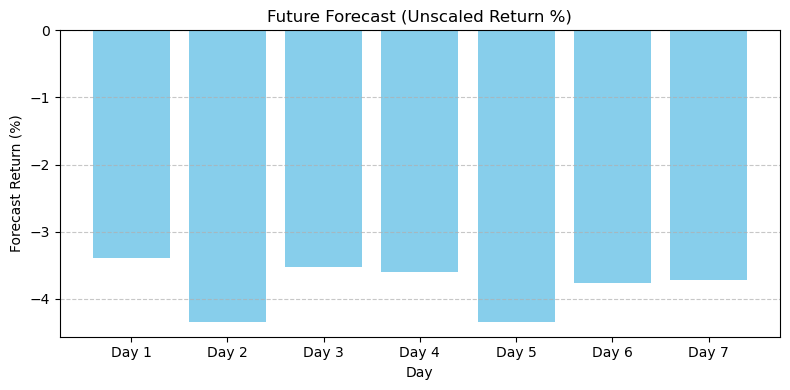

In [ ]:
# Forecast the next 5 days (scaled target predictions)
last_window = X_test_final[-1]  
future_horizon = 7  # predict next 5 days
future_preds_scaled = forecast_future(model, last_window, future_horizon, device)
print("Future forecast (scaled):", future_preds_scaled)

# Unscale the forecasted target using the scaler from the last quarter
quarter = list(scalers.keys())[-1]
scaler_q = scalers[quarter]
target_idx = len(feature_cols)  # target is the last column

# Inverse transformation:
# original_value = scaled_value / scale - (min / scale)
future_returns_unscaled = future_preds_scaled / scaler_q.scale_[target_idx] - (scaler_q.min_[target_idx] / scaler_q.scale_[target_idx])

# Format and output the results in a table
forecast_df = pd.DataFrame({
    "Day": [f"Day {i+1}" for i in range(future_horizon)],
    "Forecast Return (%)": future_returns_unscaled *100
})

print("\nFuture Forecast (Unscaled Return %):")
print(forecast_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.bar(forecast_df["Day"], forecast_df["Forecast Return (%)"], color="skyblue")
plt.title("Future Forecast (Unscaled Return %)")
plt.xlabel("Day")
plt.ylabel("Forecast Return (%)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()